In [1]:
# Run this to check which venv you are in
import os
# Virtual environment path (if active)
print("VIRTUAL_ENV:", os.environ.get("VIRTUAL_ENV", "No virtual environment active"))

VIRTUAL_ENV: C:/users/WANGMK/Source/Repos/Jupyter/.venv


# Pandas walkthrough 

This walkthrough is based on the following video: 
 [Carberra - intro jupyter (revision) and pandas](https://www.youtube.com/watch?v=bqw5-8f-cEI)

### About the Sample dataset used in this notebook

The seaborn library provides a large collection of sample datasets that can be used to demonstrate certain visualisations or properties:

df➊ = sns.load_dataset("iris"➋)

➊ Even though we are using seaborn the result of this method is a pandas dataframe

➋ iris is one of many published sample data sets that load_dataset can use. The full collection is published here: Data Sources for sample data set
Some commonly used demonstration data sets include:

- iris A classic dataset in the field of machine learning and statistics, consisting of measurements of sepals and petals of three species of iris flowers. It's perfect for introducing data manipulation, basic data visualization, and simple machine learning tasks like classification.

- titanic This dataset includes information on the Titanic passengers, such as survival status, class, age, and fare. It offers a rich context for teaching data cleaning, handling missing values, feature engineering, and exploratory data analysis, along with visualizing and modeling categorical data.

- flights The dataset records the number of passengers on commercial flights from 1949 to 1960. It can be used to teach time series analysis, data visualization techniques like line plots and heatmaps, and basic forecasting models.

- penguins Provides measurements for three species of penguins from Palmer Station, Antarctica. This is a newer dataset that's great for teaching data exploration, visualization, and statistical analysis, serving as a modern alternative to the iris dataset with a similar structure but more variability in data types and distributions.

### Import required libraries and load dataset

In [2]:
# Required libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path # modern library for working with the file system

%matplotlib inline

# Constants
DATA_DIR = 'data/'
PATTERN = '*.csv'

In [4]:
df_iris = sns.load_dataset("iris")
print(df_iris.info())
print(df_iris.describe())
print(df_iris.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000
   sepal_leng

# Cleaning the Dataset

## Handle missing values : 

The iris dataset has no missing values ( see output from info()). Therefore, there is nothing to do here.

## Handle duplicate values:

In [5]:
print((df_iris.duplicated().sum()))

1


In [5]:
# It seems there is one duplicate record
#Let's check that record

In [7]:
df_iris.loc[ df_iris.duplicated()]


,sepal_length,sepal_width,petal_length,petal_width,species
142,5.8,2.7,5.1,1.9,virginica


In [8]:
# It appears to be the entry at index 142
# Let's check the 2 records before and after that entry
dup_check = df_iris.loc[ df_iris.duplicated()].index[0]
print(dup_check)
df_iris.loc[ dup_check-1:dup_check+1]

142


,sepal_length,sepal_width,petal_length,petal_width,species
141,6.9,3.1,5.1,2.3,virginica
142,5.8,2.7,5.1,1.9,virginica
143,6.8,3.2,5.9,2.3,virginica


It is likely that there were 2 flowers with the same stats. 
If the duplicated records were next to each other, they could have been a data entry error.
But that is not the case here. Therefore, let's keep that entry for now.

Let's draw some boxplots to see if there are any outlier values ( wrong data, incorrect format/unit)

<Axes: >

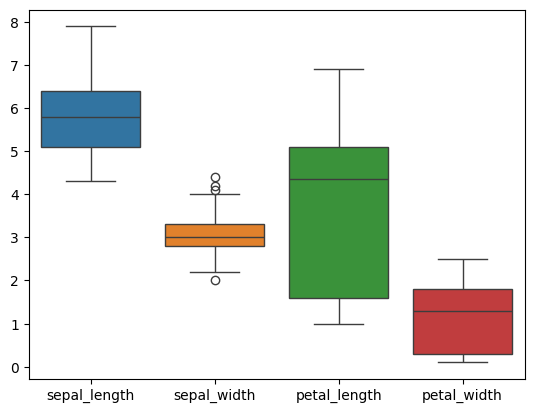

In [9]:
sns.boxplot(df_iris)

Even though there seems to be a few records with relatively large/small sepal width compared to the rest, those values are not unusual enough to be impossible. Let's keep them for now.

## Pandas provides numerous methods to manipulate data. 

### Accessing specific column(s), row(s) in a DataFrame
To access data in a DataFrame, you use the column names and row indices. Here's how you can access specific parts of the DataFrame:

Example:
- **Accessing a single column**:
  
   `df["Product"]` would return the `Product` column.
- **Accessing multiple columns**:
 
  `df[["Product", "Price"]]` would return both the `Product` and `Price` columns.
- **Accessing rows**:
 
   `df.loc[0]` would return the row indexed by 0 (the default index would start at 0)
- **Filtering data**:

    - **Excel**: Apply a filter to a column using the GUI or use a formula like `=FILTER(range, criteria)`.
    - **Pandas**: Use `df[df['column_name'] > value]` to filter rows based on column values.
  To get all rows where `Quantity` is greater than 5, use `df[df["Quantity"] > 5]`.

- **Adding a new column**:

  To add a new column that calculates the total sales (`Quantity` * `Price`), you can use `df["Total Sales"] = df["Quantity"] * df["Price"]`.
- **Aggregating data**:

  To find the total quantity sold for each product, use `df.groupby("Product")["Quantity"].sum()`.

In [10]:
# Adding a new column ( based on some calculations on other columns)
# Let's assume that the sepal area is rectangular and approximate the area calculation

df_iris['sepal_area'] =  df_iris['sepal_length'] * df_iris['sepal_width']
print( df_iris.head())


   sepal_length  sepal_width  petal_length  petal_width species  sepal_area
0           5.1          3.5           1.4          0.2  setosa       17.85
1           4.9          3.0           1.4          0.2  setosa       14.70
2           4.7          3.2           1.3          0.2  setosa       15.04
3           4.6          3.1           1.5          0.2  setosa       14.26
4           5.0          3.6           1.4          0.2  setosa       18.00


In [11]:
# Dropping a column
df_iris.drop("species", axis=1) # axis 0 -  index (rows) or 1 - columns


,sepal_length,sepal_width,petal_length,petal_width,sepal_area
0,5.1,3.5,1.4,0.2,17.85
1,4.9,3.0,1.4,0.2,14.70
2,4.7,3.2,1.3,0.2,15.04
3,4.6,3.1,1.5,0.2,14.26
4,5.0,3.6,1.4,0.2,18.00
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,20.10
146,6.3,2.5,5.0,1.9,15.75
147,6.5,3.0,5.2,2.0,19.50
148,6.2,3.4,5.4,2.3,21.08


Notice that the column 'species' is gone now but this change is only a transformation - the original dataframe is not changed. Notice that the 'species' column is still there.

In [11]:
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area
0,5.1,3.5,1.4,0.2,setosa,17.85
1,4.9,3.0,1.4,0.2,setosa,14.70
2,4.7,3.2,1.3,0.2,setosa,15.04
3,4.6,3.1,1.5,0.2,setosa,14.26
4,5.0,3.6,1.4,0.2,setosa,18.00


In [12]:
# Alternatively, df.drop( <col name> axis='columns') # can also be stated as columns and index
df_iris.drop('species', axis='columns', inplace=True)
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,sepal_area
0,5.1,3.5,1.4,0.2,17.85
1,4.9,3.0,1.4,0.2,14.70
2,4.7,3.2,1.3,0.2,15.04
3,4.6,3.1,1.5,0.2,14.26
4,5.0,3.6,1.4,0.2,18.00


## Basic plotting

Here we are just going to have a brief look at plottting (as per the video). Do note that while `seaborn` originally created the dataframe this is just a typical dataframe and the line below will work with any dataframe that has columns matching those names. 

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

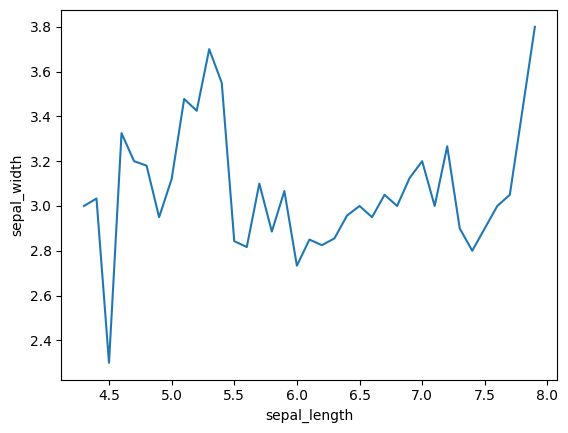

In [14]:
sns.lineplot(df_iris, x='sepal_length', y='sepal_width', errorbar=None)

In [13]:
%pip install ipympl

Note: you may need to restart the kernel to use updated packages.


In [15]:
# Try the following and the rerun the previous graph...
%matplotlib ipympl

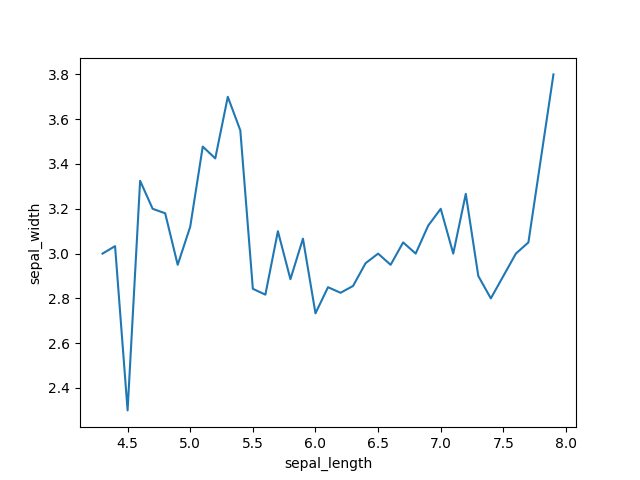

In [16]:
plt.figure()
sns.lineplot(df_iris, x='sepal_length', y='sepal_width', errorbar=None)
plt.show()

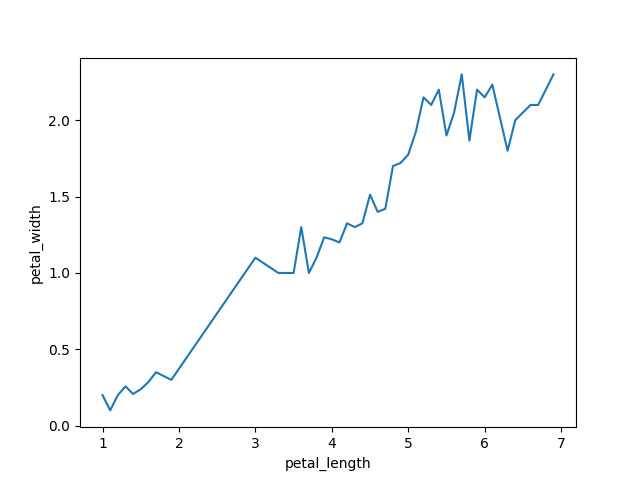

In [18]:
# TODO: Recreate the graph above, but use different columns for your x and y axis.
plt.figure() 
sns.lineplot(df_iris, x='petal_length', y='petal_width', errorbar=None)
plt.show() 





# Exercise

### Choose another sample data set:

1. View just the first few rows to be able to understand its contents
2. Remove at least one column you do not consider relevant
3. Plot a significant relationship in that data set.


## --- End of notebook ---

In [28]:
df_iris.head() 

,sepal_length,sepal_width,petal_length,petal_width,sepal_area
0,5.1,3.5,1.4,0.2,17.85
1,4.9,3.0,1.4,0.2,14.70
2,4.7,3.2,1.3,0.2,15.04
3,4.6,3.1,1.5,0.2,14.26
4,5.0,3.6,1.4,0.2,18.00


In [29]:
df_iris.drop("sepal_area", axis=1) # axis 0 -  index (rows) or 1 - columns

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


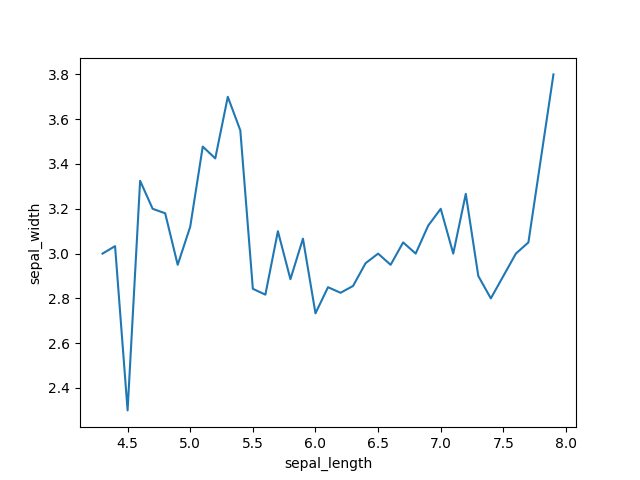

In [31]:
plt.figure() 
sns.lineplot(df_iris, x='sepal_length', y='sepal_width', errorbar=None)
plt.show() 
